##### Importation des bibliothèques et des données

In [26]:
import pandas as pd
import random
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LogisticRegression

A=pd.read_csv("population_A.csv")
B=pd.read_csv("population_B.csv")
marges_V=pd.read_csv("marges_V.csv")

##### Question 1

In [27]:
cols=["i","G","S","U","V"]
print(A[cols].equals(B[cols]))
N=len(A)
print("N =",N)
loi=A.groupby(["G","S","U"]).size().to_frame("effectif")
loi["proportion"]=loi["effectif"]/N
print(loi)

True
N = 20000
       effectif  proportion
G S U                      
1 0 0      1317     0.06585
    1      1600     0.08000
  1 0      1320     0.06600
    1      1612     0.08060
2 0 0      2206     0.11030
    1      1746     0.08730
  1 0      2297     0.11485
    1      1861     0.09305
3 0 0      1902     0.09510
    1      1033     0.05165
  1 0      2015     0.10075
    1      1091     0.05455


##### Question 2.a
$$\widehat p = \frac{1}{n}\sum_{i=1}^{N} \mathbb 1_{\{i\in R\}}\, Y_i$$

puis

$$\mathbb E(\widehat p) = \frac{1}{n}\sum_{i=1}^{N} Y_i\,\mathbb P(i\in R)$$

or

$$\mathbb P(i\in R) = \frac{\binom{N-1}{n-1}}{\binom{N}{n}} = \frac{\binom{N-1}{n-1}}{\frac{N}{n}\binom{N-1}{n-1}} = \frac{n}{N}$$

donc

$$\mathbb E(\widehat p) = \frac{1}{n}\sum_{i=1}^{N} Y_i\,\frac{n}{N} = \frac{1}{N}\sum_{i=1}^{N} Y_i = p$$

donc $\boxed{\widehat p \text{ est sans biais}}$.


##### Question 2.b
$$
\begin{aligned}
\mathbb V(\widehat p) &= \mathbb E\Big[\big(\widehat p - \mathbb E(\widehat p)\big)^2\Big] \\
&= \mathbb E\big[(\widehat p - p)^2\big] \\
&= \mathbb E\Big[\Big(\frac{1}{n}\sum_{i\in R}(Y_i - p)\Big)^2\Big] \\
&= \frac{1}{n^2}\,\mathbb E\Big[\Big(\sum_{i=1}^{N}(Y_i - p)\,\mathbb 1_{\{i\in R\}}\Big)^2\Big]
\end{aligned}
$$

or

$$\Big(\sum_{i=1}^{N}(Y_i-p)\,\mathbb 1_{\{i\in R\}}\Big)^2 = \sum_{i=1}^{N}(Y_i-p)^2\,\mathbb 1_{\{i\in R\}} + \sum_{i\neq j}(Y_i-p)(Y_j-p)\,\mathbb 1_{\{i\in R\}}\,\mathbb 1_{\{j\in R\}}$$

donc

$$
\begin{aligned}
\mathbb V(\widehat p) &= \frac{1}{n^2}\sum_{i=1}^{N}(Y_i-p)^2\,\frac{n}{N} + \frac{1}{n^2}\sum_{i\neq j}(Y_i-p)(Y_j-p)\,\frac{\binom{N-2}{n-2}}{\binom{N}{n}} \\
&= \frac{1}{nN}\sum_{i=1}^{N}(Y_i-p)^2 + \frac{n-1}{nN(N-1)}\sum_{i\neq j}(Y_i-p)(Y_j-p)
\end{aligned}
$$

or $\displaystyle\sum_{i=1}^{N}(Y_i-p) = \sum_{i=1}^{N}Y_i - Np = 0$, donc

$$\sum_{i\neq j}(Y_i-p)(Y_j-p) = -\sum_{i=1}^{N}(Y_i-p)^2 = -(N-1)S_Y^2$$

donc

$$
\begin{aligned}
\mathbb V(\widehat p) &= \frac{1}{nN}(N-1)S_Y^2 - \frac{(n-1)(N-1)}{nN(N-1)}S_Y^2 \\
&= \Big(\frac{N-1}{N} - \frac{n-1}{N}\Big)\frac{S_Y^2}{n} \\
&= \boxed{\Big(1-\frac{n}{N}\Big)\frac{S_Y^2}{n}}
\end{aligned}
$$

et

$$
\begin{aligned}
S_Y^2 &= \frac{1}{N-1}\sum_{i=1}^{N}\big(Y_i^2 + p^2 - 2Y_i p\big) \\
&= \frac{1}{N-1}\sum_{i=1}^{N}\big(Y_i(1-2p) + p^2\big) \qquad (\text{car } Y_i^2 = Y_i) \\
&= \frac{1}{N-1}\big((1-2p)\,Np + Np^2\big) \\
&= \boxed{\frac{N}{N-1}\,p(1-p)}
\end{aligned}
$$

##### Question 2.c
$$\widehat S_Y^2 = \frac{1}{n-1}\sum_{i\in R}(Y_i - \widehat p)^2 = \frac{n}{n-1}\,\widehat p(1-\widehat p)$$

$$\boxed{\widehat{\mathbb V}(\widehat p) = \Big(1-\frac{n}{N}\Big)\frac{\widehat S_Y^2}{n} = \Big(1-\frac{n}{N}\Big)\frac{\widehat p(1-\widehat p)}{n-1}}$$

On tire $J_1,\dots,J_n$ i.i.d. de loi $\mathcal U(\llbracket 1,N\rrbracket)$, où $J_k$ est l'identifiant de la $k$-ième personne interrogée. On pose $Z_k = Y_{J_k}$ : les $(Z_k)_{1\le k\le n}$ sont i.i.d. Si les $J_k$ sont tous distincts,

$$\overline Z_n = \frac{1}{n}\sum_{k=1}^{n} Z_k = \widehat p.$$

De plus, les $Z_k$ sont de carré intégrable, donc par le TCL :

$$\sqrt n\,(\overline Z_n - p) \xrightarrow[n\to+\infty]{\text{loi}} \mathcal N\big(0,\,p(1-p)\big)$$

c'est-à-dire

$$\sqrt n\,(\widehat p - p) \xrightarrow{\text{loi}} \mathcal N\big(0,\,p(1-p)\big), \qquad \frac{\sqrt n\,(\widehat p - p)}{\sqrt{p(1-p)}} \xrightarrow{\text{loi}} \mathcal N(0,1)$$

Par **Slutsky** :

$$\frac{\sqrt n\,(\widehat p - p)}{\sqrt{\widehat p(1-\widehat p)}} \xrightarrow{\text{loi}} \mathcal N(0,1)$$

d'où

$$\mathbb P\left(-z_{1-\frac{\alpha}{2}} \le \frac{\widehat p - p}{\sqrt{\widehat{\mathbb V}(\widehat p)}} \le z_{1-\frac{\alpha}{2}}\right) \longrightarrow 1-\alpha$$

donc

$$IC_{1-\alpha}(p) = \Big[\,\widehat p \pm z_{1-\frac{\alpha}{2}}\sqrt{\widehat{\mathbb V}(\widehat p)}\,\Big]$$

or

$$
\begin{aligned}
\widehat{\mathbb V}(\widehat p) &= \Big(1-\frac{n}{N}\Big)\frac{\widehat S_Y^2}{n} \\
&= \Big(1-\frac{n}{N}\Big)\times\frac{N}{N-1}\times\frac{1}{n}\,\widehat p(1-\widehat p) \\
&= \frac{N-n}{N-1}\times\frac{\widehat p(1-\widehat p)}{n}
\end{aligned}
$$

donc

$$IC_{1-\alpha}(p) = \left[\,\widehat p \pm z_{1-\frac{\alpha}{2}}\sqrt{\frac{N-n}{n(N-1)}\,\widehat p(1-\widehat p)}\,\right]$$

##### Question 2.d

In [28]:
def simulation_2(population,n=800,M=500,alpha=0.05):
    N=len(population)
    p_chapeau=[]
    p=population["Y"].mean()
    RMSE=0
    proportion=0
    longueurs=[]
    z=norm.ppf(1-alpha/2)
    for i in range(M):
        indices=random.sample(range(N),n) # n numéros de ligne distincts parmi 0, ..., N-1
        R=population.iloc[indices]
        p_chapeau_i=R["Y"].mean()
        RMSE+=(p_chapeau_i-p)**2
        p_chapeau.append(p_chapeau_i)
        var_hat=(1-n/N)*p_chapeau_i*(1-p_chapeau_i)/(n-1)
        demi_longueur=z*np.sqrt(var_hat)
        if np.abs(p_chapeau_i-p)<=demi_longueur:
            proportion+=1
        longueurs.append(2*demi_longueur)

    longueurs=np.array(longueurs)
    longueur_moy=longueurs.mean()
    proportion=proportion/M
    RMSE=np.sqrt(RMSE/M)
    p_chapeau=np.array(p_chapeau)
    moyenne=p_chapeau.mean()
    biais_empirique=moyenne-p
    variance_empirique=p_chapeau.var()

    return(moyenne,biais_empirique,variance_empirique,RMSE,proportion,longueur_moy,p_chapeau)

Population A :
(np.float64(0.5126575), np.float64(0.0011575000000000335), np.float64(0.00032784706875), np.float64(0.01814350779204505), 0.936, np.float64(0.06787121042818847))
Population B :
(np.float64(0.52527), np.float64(2.0000000000020002e-05), np.float64(0.0003149896000000001), np.float64(0.01774795762897806), 0.932, np.float64(0.06780779938209493))


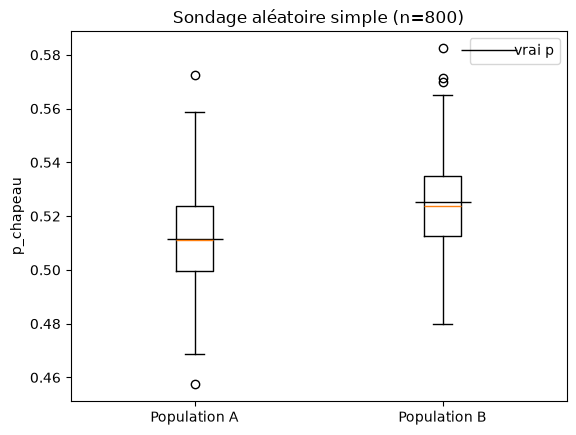

In [29]:
print("Population A :")
print(simulation_2(A)[:6])
print("Population B :")
print(simulation_2(B)[:6])

plt.boxplot([simulation_2(A)[6],simulation_2(B)[6]])
plt.xticks([1,2],["Population A","Population B"])
plt.plot(1,A["Y"].mean(),"k_",markersize=40,label="vrai p")
plt.plot(2,B["Y"].mean(),"k_",markersize=40)
plt.ylabel("p_chapeau")
plt.title("Sondage aléatoire simple (n=800)")
plt.legend()
plt.show()

##### Question 3.a

- Les lignes représentent $n$.
- Les colonnes représentent $\widehat p$ en pourcentage.
- $\alpha$ est fixé à 5 %.
- Les cases représentent $\displaystyle z_{0,975}\sqrt{\frac{N-n}{n(N-1)}\,\widehat p(1-\widehat p)}\times 100$, mais avec la limite $N\to+\infty$, donc $\displaystyle z_{0,975}\sqrt{\frac{\widehat p(1-\widehat p)}{n}}\times 100$.

Pour un $n$ donné, $\widehat p$ et $1-\widehat p$ représentent le même intervalle, ce qui justifie la symétrie dans les colonnes.

Par exemple, pour $n = 13\,060$ et $\widehat p = 5\,\%$, on a

$$z_{0,975}\sqrt{\frac{0{,}05\times(1-0{,}05)}{13\,060}}\times 100 \simeq 0{,}37.$$

##### Question 3.b

- Si $1-\alpha$ augmente, $z_{1-\alpha/2}$ augmente, donc l'amplitude est croissante en fonction du niveau de confiance.
- L'amplitude est en $\sqrt{x(1-x)}$ en fonction de l'observation.
- L'amplitude est en $\dfrac{1}{\sqrt n}$ en fonction de la taille de l'échantillon.

##### Question 3.c

$p$ est une constante, pas une variable aléatoire : une fois l'intervalle calculé, soit il contient $p$, soit il ne le contient pas.

##### Question 4.a

$$\mathbb E(\widehat p_{\text{strat}}) = \sum_{h=1}^{H} W_h\,\mathbb E(\overline Y_h)$$

De la même manière qu'à la question 2 :

$$\mathbb E(\overline Y_h) = \frac{1}{N_h}\sum_{i\in N_h} Y_i$$

puis

$$\mathbb E(\widehat p_{\text{strat}}) = \frac{1}{N}\sum_{h=1}^{H}\Big(\sum_{i\in N_h} Y_i\Big) = \frac{1}{N}\sum_{i=1}^{N} Y_i = p$$

donc $\boxed{\widehat p_{\text{strat}} \text{ est sans biais}}$.

De la même manière qu'à la question 2 :

$$\mathbb V(\overline Y_h) = \Big(1-\frac{n_h}{N_h}\Big)\frac{S_{Y,h}^2}{n_h}$$

puis les $(n_h, R_h)_{1\le h\le H}$ sont mutuellement indépendants, donc les $(\overline Y_h)$ aussi, donc

$$\boxed{\mathbb V(\widehat p_{\text{strat}}) = \sum_{h=1}^{H} W_h^2\,\mathbb V(\overline Y_h) = \sum_{h=1}^{H} W_h^2\Big(1-\frac{n_h}{N_h}\Big)\frac{S_{Y,h}^2}{n_h}}$$

avec

$$S_{Y,h}^2 = \frac{1}{N_h-1}\sum_{i\in N_h}(Y_i - p_h)^2 = \frac{N_h}{N_h-1}\,p_h(1-p_h), \qquad p_h = \frac{1}{N_h}\sum_{i\in N_h} Y_i$$

donc

$$\boxed{\widehat{\mathbb V}(\widehat p_{\text{strat}}) = \sum_{h=1}^{H} W_h^2\Big(1-\frac{n_h}{N_h}\Big)\frac{N_h}{N_h-1}\,\widehat p_{\text{strat},h}\big(1-\widehat p_{\text{strat},h}\big)}$$

##### Question 4.b

On pose

$$f : (\mathbb R^*)^H \to \mathbb R, \qquad (n_1,\dots,n_H) \mapsto \sum_h W_h\,\frac{S_{Y,h}^2}{n_h}$$

et

$$g : \mathbb R^H \to \mathbb R, \qquad (n_1,\dots,n_H) \mapsto \Big(\sum_h n_h\Big) - n$$

$f$ et $g$ sont $\mathcal C^1$. On cherche un extremum local de $f$ en $(n_1^0,\dots,n_H^0) \in X = g^{-1}(\{0\})$.

Or

$$\nabla g = \begin{pmatrix}1\\ \vdots\\ 1\end{pmatrix} \neq 0$$

donc

$$\nabla f(n_1^0,\dots,n_H^0) = \lambda\begin{pmatrix}1\\ \vdots\\ 1\end{pmatrix}$$

puis

$$-\frac{W_h^2 S_{Y,h}^2}{n_h^2} = \lambda \;\Longrightarrow\; -\frac{W_h^2 S_{Y,h}^2}{\lambda} = n_h^2$$

$$\Longrightarrow\; \boxed{n_h \propto W_h S_{Y,h} \propto N_h S_{Y,h}}$$

Cette allocation n'est pas utilisable car les $S_{Y,h}$ sont inconnus avant l'enquête.

##### Question 5

In [30]:
def allocation(N_h, S_h, n, n_min=2):
    strates=list(N_h.keys())
    H=len(strates)
    poids=np.array([N_h[h]*S_h[h] for h in strates],dtype=float)
    if poids.sum() == 0:                 # tous les S_h estimés sont nuls
        poids=np.array([N_h[h] for h in strates],dtype=float)   # → proportionnelle

    reste=n-n_min*H  #allouer le reste
    cible=reste*poids/poids.sum()  # parts non entières
    n_alloc=np.floor(cible).astype(int)
    manque=reste-n_alloc.sum()   # unités perdues à l'arrondi
    ordre=np.argsort(-(cible-n_alloc))   # plus grandes parties décimales d'abord
    n_alloc[ordre[:manque]] += 1
    n_alloc+=n_min  #garantir que chaque n_h>=2
    return dict(zip(strates, n_alloc))

In [31]:
def calcul(strates,d,b,N):
    p_strat=0
    var_strat=0
    for h, g in strates:
            indices=random.sample(range(len(g)),d[h])
            echantillon_h=g.iloc[indices]
            Y_h=echantillon_h["Y"]
            Y_h_barre=np.sum(Y_h)/d[h]
            W_h=b[h]/N
            S2_h=np.sum((Y_h-Y_h_barre)**2)/(d[h]-1)
            p_strat+=W_h*Y_h_barre
            var_strat+=W_h**2*((1-d[h]/b[h])*S2_h/d[h])
    return p_strat,var_strat
    

In [32]:
def comparer(population,n=800,M=500,alpha=0.05):
    strates=population.groupby(["G","S","U"])
    N=len(population)
    N_h={h: len(g) for h, g in strates} #dictionnaire strate:effectif
    p_strat=[]
    var_strat=[]
    #Méthode proportionnelle
    n_h_prop=allocation(N_h,{h: 1 for h in N_h},n)
    
    #Methode Neyman_Oracle
    Y_strates={h:g["Y"].tolist() for h,g in strates}
    S_oracle={}
    for h,Y in Y_strates.items():
        p_h=sum(Y)/len(Y)                        
        somme=0
        for y in Y:
            somme+=(y-p_h)**2
        S_oracle[h]=np.sqrt(somme/(len(Y)-1))
    n_h_oracle=allocation(N_h,S_oracle,n)
    
    for rep in range(M):
        p_strat_methodes=[]
        var_strat_methodes=[]
        #Méthode proportionnelle
        p_strat_prop,var_strat_prop=calcul(strates,n_h_prop,N_h,N)
        
        p_strat_methodes.append(p_strat_prop)
        var_strat_methodes.append(var_strat_prop)
        
        #Méthode Neyman_Pilote
        S_pilote={}
        for h,groupe in strates:
            indices=random.sample(range(len(groupe)),20)
            pilote_h=groupe.iloc[indices]
            Y_pilote_h=pilote_h["Y"]
            p=Y_pilote_h.mean()
            S_Y_h=0
            for y in Y_pilote_h:
                S_Y_h+=(y-p)**2
            S_Y_h=np.sqrt(S_Y_h/19)
            S_pilote[h]=S_Y_h
        n_h=allocation(N_h,S_pilote,n)
        p_strat_pilote,var_strat_pilote=calcul(strates,n_h,N_h,N)
        
        p_strat_methodes.append(p_strat_pilote)
        var_strat_methodes.append(var_strat_pilote)
        
        #Methode Neyman_Oracle
        p_strat_oracle,var_strat_oracle=calcul(strates,n_h_oracle,N_h,N)
        
        p_strat_methodes.append(p_strat_oracle)
        var_strat_methodes.append(var_strat_oracle)
        
        p_strat.append(p_strat_methodes)
        var_strat.append(var_strat_methodes)
        
    p=population["Y"].mean()
    z=norm.ppf(1-alpha/2)
    P=np.array(p_strat)        # P[k,j]=p_strat de la répétition k, méthode j
    V=np.array(var_strat)      # V[k,j]=var_strat de la répétition k, méthode j
    demi_longueur=z*np.sqrt(V)                     # demi-longueur[k,j], demi-longueur de la répétition k, méthode j
    couvre = np.abs(P-p)<=demi_longueur            

    return(P.mean(axis=0),P.mean(axis=0)-p,P.var(axis=0),np.sqrt(((P-p)**2).mean(axis=0)),couvre.mean(axis=0),(2*demi_longueur).mean(axis=0),P)

Population A :
(array([0.51169413, 0.51178167, 0.51192224]), array([0.00019413, 0.00028167, 0.00042224]), array([0.00029275, 0.00029443, 0.00027027]), array([0.01711108, 0.01716137, 0.01644521]), array([0.936, 0.938, 0.95 ]), array([0.06379656, 0.06533859, 0.06352456]))
Population B :
(array([0.52537838, 0.52590397, 0.52411393]), array([ 0.00012838,  0.00065397, -0.00113607]), array([0.00030504, 0.00030437, 0.00027234]), array([0.01746583, 0.01745834, 0.01654177]), array([0.948, 0.942, 0.95 ]), array([0.06776963, 0.06781223, 0.06777269]))


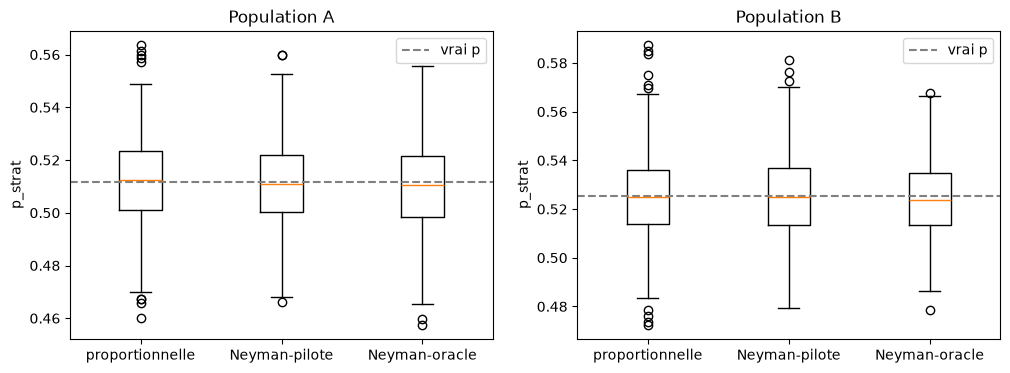

In [33]:
print("Population A :")
print(comparer(A)[:6])
print("Population B :")
print(comparer(B)[:6])

noms=["proportionnelle","Neyman-pilote","Neyman-oracle"]
fig,ax=plt.subplots(1,2,figsize=(12,4))
for j,(nom,pop) in enumerate([("A",A),("B",B)]):
    P=comparer(pop)[6]
    ax[j].boxplot([P[:,k] for k in range(3)])
    ax[j].set_xticks([1,2,3])
    ax[j].set_xticklabels(noms)
    ax[j].axhline(pop["Y"].mean(),color="gray",linestyle="--",label="vrai p")
    ax[j].set_title("Population "+nom)
    ax[j].set_ylabel("p_strat")
    ax[j].legend()
plt.show()

##### Question 6

La stratification réduit l'erreur de sondage dans la mesure où $Y$ varie d'une strate à l'autre.

##### Question 7

Sexe, âge, profession, région, catégorie d'agglomération.

##### Question 8.a

Les participants sont contactés en ligne via l'Access Panel d'Ipsos. Ils sont rémunérés, mais très peu. Il y a des millions de membres dans l'Access Panel Ipsos.

##### Question 8.b

- L'inscription est facile, gratuite et ouverte à tous.
- On choisit de participer, mais pas l'enquête à laquelle on est invité : pour chaque invitation, on choisit de répondre ou non.

##### Question 9

Non : les personnes les plus disponibles, les plus connectées ou les plus intéressées sont sur-représentées.

##### Question 10.a

In [34]:
def recrutement(population,n=800):
    D=population["D"].to_numpy()
    echelles=np.exp(-D)
    T=np.random.exponential(echelles)
    ordre=np.argsort(T)
    population_triee=population.iloc[ordre]
    quotas={}
    compteur={}
    for var in ["G","S","U"]:
        effectifs=population[var].value_counts().sort_index().to_dict()
        quotas[var]=allocation(effectifs,{m:1 for m in effectifs},n,n_min=0)
        compteur[var]={}
    individus_recrutes=[]
    for i,g,s,u in zip(population_triee.index,population_triee["G"],population_triee["S"],population_triee["U"]):
        if compteur["G"].get(g,0)<quotas["G"][g] and compteur["S"].get(s,0)<quotas["S"][s] and compteur["U"].get(u,0)<quotas["U"][u]:
            individus_recrutes.append(i)
            compteur["G"][g]=compteur["G"].get(g,0)+1
            compteur["S"][s]=compteur["S"].get(s,0)+1
            compteur["U"][u]=compteur["U"].get(u,0)+1
        if len(individus_recrutes)==n:
            break
    return population.loc[individus_recrutes]
R=recrutement(A)
Q=recrutement(B)
print("Population A :")
print(len(R))
for var in ["G","S","U"]:
    print(var,R[var].value_counts().sort_index().to_dict())

print("Population B :")
print(len(Q))
for var in ["G","S","U"]:
    print(var,Q[var].value_counts().sort_index().to_dict())




Population A :
800
G {1: 234, 2: 324, 3: 242}
S {0: 392, 1: 408}
U {0: 442, 1: 358}
Population B :
800
G {1: 234, 2: 324, 3: 242}
S {0: 392, 1: 408}
U {0: 442, 1: 358}


##### Question 10.b

In [35]:
def simulation_10(population,n=800,M=500,alpha=0.05):
    
    N=len(population)
    p_chapeau=[]
    p=population["Y"].mean()
    RMSE=0
    proportion=0
    longueurs=[]
    z=norm.ppf(1-alpha/2)
    for i in range(M):
        R=recrutement(population,n)
        p_chapeau_i=R["Y"].mean()
        RMSE+=(p_chapeau_i-p)**2
        p_chapeau.append(p_chapeau_i)
        var_hat=(1-n/N)*p_chapeau_i*(1-p_chapeau_i)/(n-1)
        demi_longueur=z*np.sqrt(var_hat)
        if np.abs(p_chapeau_i-p)<=demi_longueur:
            proportion+=1
        longueurs.append(2*demi_longueur)

    longueurs=np.array(longueurs)
    longueur_moy=longueurs.mean()
    proportion=proportion/M
    RMSE=np.sqrt(RMSE/M)
    p_chapeau=np.array(p_chapeau)
    moyenne=p_chapeau.mean()
    biais_empirique=moyenne-p
    variance_empirique=p_chapeau.var()

    return(moyenne,biais_empirique,variance_empirique,RMSE,proportion,longueur_moy,p_chapeau)

Population A :
(np.float64(0.5344525000000001), np.float64(0.022952500000000153), np.float64(0.00027537836875), np.float64(0.02832305818586688), 0.726, np.float64(0.06773843758333717))
Population B :
(np.float64(0.7003550000000001), np.float64(0.17510500000000007), np.float64(0.00022515522499999996), np.float64(0.17574673894556342), 0.0, np.float64(0.06220490824723211))


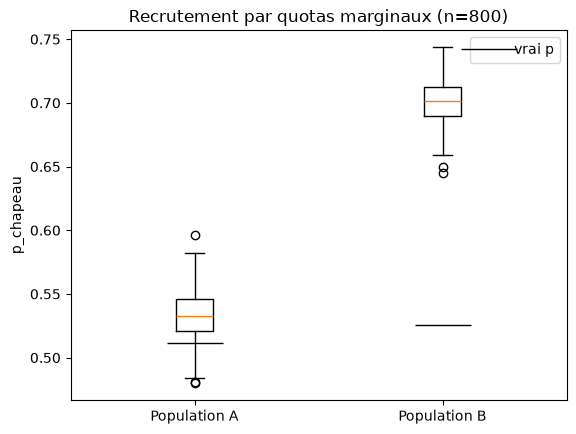

In [36]:
print("Population A :")
print(simulation_10(A)[:6])
print("Population B :")
print(simulation_10(B)[:6])

plt.boxplot([simulation_10(A)[6],simulation_10(B)[6]])
plt.xticks([1,2],["Population A","Population B"])
plt.plot(1,A["Y"].mean(),"k_",markersize=40,label="vrai p")
plt.plot(2,B["Y"].mean(),"k_",markersize=40)
plt.ylabel("p_chapeau")
plt.title("Recrutement par quotas marginaux (n=800)")
plt.legend()
plt.show()

##### Question 10.d
L'estimateur naïf $\widehat p_{\text{quota}}$ est biaisé vers le haut dans les deux populations :

- **Population A:** biais $\approx +0{,}02$. L'intervalle naïf ne couvre $p$ que dans $\approx 77\,\%$ des cas au lieu de $95\,\%$.
- **Population B:** biais $\approx +0{,}18$. La couverture est de $0\,\%$.

L'absence de biais utilisait $\mathbb P(i\in R)=n/N$ pour tout $i$. Ici, les probabilités d'inclusion sont inégales (elles augmentent avec $D_i$) et inconnues, donc rien ne garantit $\mathbb E[\widehat p]=p$.

##### Question 11.a
$$\sum_i w_i = \left\langle \begin{pmatrix}w_{i_1}\\ \vdots\\ w_{i_n}\end{pmatrix}, \begin{pmatrix}1\\ \vdots\\ 1\end{pmatrix} \right\rangle$$

donc, par l'inégalité de Cauchy-Schwarz :

$$
\begin{aligned}
\Big(\sum_i w_i\Big)^2 &\le \left\|\begin{pmatrix}w_{i_1}\\ \vdots\\ w_{i_n}\end{pmatrix}\right\|^2 \times \left\|\begin{pmatrix}1\\ \vdots\\ 1\end{pmatrix}\right\|^2 \\
&= \Big(\sum_i w_i^2\Big)\times\Big(\sum_i 1\Big) \\
&= n\Big(\sum_i w_i^2\Big)
\end{aligned}
$$

donc $n_{\text{eff}} \le n$, avec égalité si et seulement si $\begin{pmatrix}w_{i_1}\\ \vdots\\ w_{i_n}\end{pmatrix}$ et $\begin{pmatrix}1\\ \vdots\\ 1\end{pmatrix}$ sont colinéaires, c'est-à-dire si et seulement si les $w_i$ sont égaux.


##### Question

In [37]:
def recrutement_plafond(population,n=800,delta=0.3):
    D=population["D"].to_numpy()
    echelles=np.exp(-D)
    T=np.random.exponential(echelles)
    ordre=np.argsort(T)
    population_triee=population.iloc[ordre]
    quotas={}
    compteur={}
    plafonds={}
    for var in ["G","S","U"]:
        effectifs=population[var].value_counts().sort_index().to_dict()
        quotas[var]=allocation(effectifs,{m:1 for m in effectifs},n,n_min=0)
        compteur[var]={}
        plafonds[var]={m:math.ceil((1+delta)*quotas[var][m]) for m in quotas[var].keys()}
    individus_recrutes=[]
    for i,g,s,u in zip(population_triee.index,population_triee["G"],population_triee["S"],population_triee["U"]):
        if compteur["G"].get(g,0)<plafonds["G"][g] and compteur["S"].get(s,0)<plafonds["S"][s] and compteur["U"].get(u,0)<plafonds["U"][u]:
            individus_recrutes.append(i)
            compteur["G"][g]=compteur["G"].get(g,0)+1
            compteur["S"][s]=compteur["S"].get(s,0)+1
            compteur["U"][u]=compteur["U"].get(u,0)+1
        if len(individus_recrutes)==n:
            break
    return population.loc[individus_recrutes]
R=recrutement(A)
Q=recrutement(B)
print("Population A :")
print(len(R))
for var in ["G","S","U"]:
    print(var,R[var].value_counts().sort_index().to_dict())

print("Population B :")
print(len(Q))
for var in ["G","S","U"]:
    print(var,Q[var].value_counts().sort_index().to_dict())

Population A :
800
G {1: 234, 2: 324, 3: 242}
S {0: 392, 1: 408}
U {0: 442, 1: 358}
Population B :
800
G {1: 234, 2: 324, 3: 242}
S {0: 392, 1: 408}
U {0: 442, 1: 358}


In [38]:
def calage(marges,R,epsilon=1e-8):
    n=len(R)
    N=sum(marges["G"].values())
    colonnes={var:R[var].to_numpy() for var in marges}
    poids=np.full(n,N/n)

    for i in range(1000):
        for var,marges_var in marges.items():
            for m in marges_var.keys():
                S=poids[colonnes[var]==m].sum()
                poids[colonnes[var]==m]*=marges_var[m]/S
                

        ecart_max=0
        for var,marges_var in marges.items():
            for m,N_m in marges_var.items():
                ecart=abs(poids[colonnes[var]==m].sum()-N_m)
                ecart_max=max(ecart_max,ecart)
        if ecart_max<epsilon:
            break
    return poids

marges={var:A[var].value_counts().sort_index().to_dict() for var in ["G","S","U"]}
marges_avec_V={**marges,"V":dict(zip(marges_V["V"],marges_V["effectif"]))}

R=recrutement_plafond(A)
poids=calage(marges,R)
p_cal=(poids*R["Y"].to_numpy()).sum()/poids.sum()
print("Population A :")
print("p_cal=",p_cal)
poids_avec_V=calage(marges_avec_V,R)
p_cal_avec_V=(poids_avec_V*R["Y"].to_numpy()).sum()/poids_avec_V.sum()
print("p_cal_avec_V=",p_cal_avec_V)

Q=recrutement_plafond(B)
poids=calage(marges,Q)
p_cal=(poids*Q["Y"].to_numpy()).sum()/poids.sum()
print("Population B :")
print("p_cal=",p_cal)
poids_avec_V=calage(marges_avec_V,Q)
p_cal_avec_V=(poids_avec_V*Q["Y"].to_numpy()).sum()/poids_avec_V.sum()
print("p_cal_avec_V=",p_cal_avec_V)



Population A :
p_cal= 0.5496188320884966
p_cal_avec_V= 0.5480617734513545
Population B :
p_cal= 0.7048939910391496
p_cal_avec_V= 0.6074229132972322


In [39]:
def poids_ipw(population,R):
    Z=population.index.isin(R.index).astype(int)
    #indicatrices de G,S,U
    X=pd.get_dummies(population[["G","S","U"]].astype(str),drop_first=True).astype(float)
    modele=LogisticRegression(C=1e10,max_iter=1000)
    modele.fit(X,Z)
    pi_chapeau=modele.predict_proba(X.loc[R.index])[:,1]   #propensions estimées des répondants
    return 1/pi_chapeau

def estimateur_pondere(poids,R):
    return (poids*R["Y"].to_numpy()).sum()/poids.sum()

def n_eff(poids):
    return poids.sum()**2/(poids**2).sum()

def simulation_11(population,marges_V,n=800,M=500,alpha=0.05):
    N=len(population)
    p=population["Y"].mean()
    z=norm.ppf(1-alpha/2)
    marges={var:population[var].value_counts().sort_index().to_dict() for var in ["G","S","U"]}
    marges_avec_V={**marges,"V":dict(zip(marges_V["V"],marges_V["effectif"]))}
    P=[]     #P[k][j]: estimation de la répétition k, méthode j
    D=[]     #D[k][j]: demi-longueur de l'intervalle (Kish) de la répétition k, méthode j
    NE=[]    #NE[k][j]: taille effective n_eff de la répétition k, méthode j
    for k in range(M):
        R=recrutement_plafond(population,n)
        liste_poids=[np.full(len(R),N/len(R)),            #brut
                     calage(marges,R),
                     calage(marges_avec_V,R),
                     poids_ipw(population,R)]
        P_k,D_k,NE_k=[],[],[]
        for w in liste_poids:
            p_w=estimateur_pondere(w,R)
            ne=n_eff(w)
            var_kish=(1-ne/N)*p_w*(1-p_w)/ne
            P_k.append(p_w)
            D_k.append(z*np.sqrt(var_kish))
            NE_k.append(ne)
        P.append(P_k);D.append(D_k);NE.append(NE_k)
    P=np.array(P);D=np.array(D);NE=np.array(NE)
    couvre=np.abs(P-p)<=D
    moyenne=P.mean(axis=0)
    biais_empirique=moyenne-p
    variance_empirique=P.var(axis=0)
    RMSE=np.sqrt(((P-p)**2).mean(axis=0))
    proportion=couvre.mean(axis=0)
    longueur_moy=(2*D).mean(axis=0)
    n_eff_moy=NE.mean(axis=0)
    return(moyenne,biais_empirique,variance_empirique,RMSE,proportion,longueur_moy,n_eff_moy,P)

print(simulation_11(A,marges_V)[:7])
print(simulation_11(B,marges_V)[:7])

(array([0.542575  , 0.50902973, 0.50845231, 0.5084708 ]), array([ 0.031075  , -0.00247027, -0.00304769, -0.0030292 ]), array([0.00028236, 0.00036423, 0.00035753, 0.00036838]), array([0.03532731, 0.01924394, 0.01915238, 0.01943083]), array([0.576, 0.954, 0.96 , 0.956]), array([0.06760976, 0.07548427, 0.07554832, 0.07589692]), array([800.        , 651.38720551, 650.36440183, 644.64566167]))
(array([0.7054325 , 0.70081055, 0.60225699, 0.70072192]), array([0.1801825 , 0.17556055, 0.07700699, 0.17547192]), array([0.00022086, 0.00029245, 0.00039102, 0.00029483]), array([0.18079434, 0.17639147, 0.07950535, 0.17631003]), array([0.  , 0.  , 0.04, 0.  ]), array([0.06186005, 0.06925493, 0.08372503, 0.06956762]), array([800.        , 649.15758836, 511.55397954, 643.70075666]))


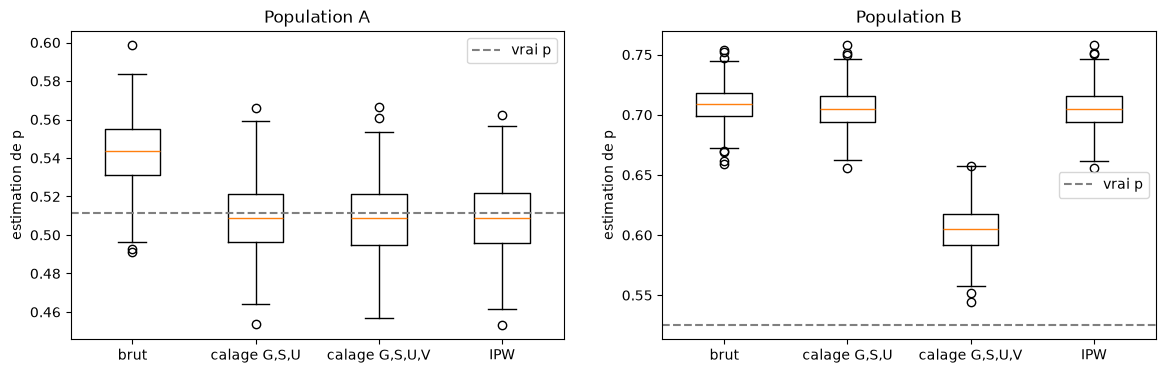

In [40]:
noms=["brut","calage G,S,U","calage G,S,U,V","IPW"]
resA=simulation_11(A,marges_V)
resB=simulation_11(B,marges_V)
fig,ax=plt.subplots(1,2,figsize=(14,4))
for j,(nom,pop,res) in enumerate([("A",A,resA),("B",B,resB)]):
    P=res[7]
    ax[j].boxplot([P[:,k] for k in range(4)])
    ax[j].set_xticks([1,2,3,4])
    ax[j].set_xticklabels(noms)
    ax[j].axhline(pop["Y"].mean(),color="gray",linestyle="--",label="vrai p")
    ax[j].set_title("Population "+nom)
    ax[j].set_ylabel("estimation de p")
    ax[j].legend()
plt.show()

##### Question 11.c
- L'estimateur brut est biaisé dans les deux populations.
- Le redressement réduit le biais, mais la variance augmente.
- Le calage sur $G,S,U$ et l'IPW donnent des résultats presque identiques.
- Ajouter $V$ au calage est utile dans le cas de B, pas dans A.

- **Population A:** Les trois méthodes ramènent le biais à environ 0 et la couverture à environ 95 %.
- **Population B:** Le calage sur $G,S,U$ et l'IPW ne corrigent presque rien (biais ≈ +0,18).


##### Question 12.a

Oui, des quotas ont été utilisés. *« L'échantillon a été constitué selon la méthode des quotas, au regard des critères de sexe, d'âge, de catégorie socioprofessionnelle, de catégorie d'agglomération et de région de résidence. »* L'échantillon compte 1 153 personnes, dont 1 095 inscrites sur les listes électorales, interrogées en ligne.

Dans l'échantillon brut, il y a 49 % d'hommes.

La colonne BRUT correspond à l'estimateur $\widehat p_{\text{quota}}$ de la question 10. La colonne Socio-Démo correspond au premier calage sur $G, S, U$.



##### Question 12.b

Le redressement a été fait sur :
- les variables sociodémographiques (sexe, âge, CSP, agglomération, région).
- le vote au 1er tour de la présidentielle 2022 et le vote au 1er tour des législatives 2022.
- le vote aux européennes 2024.

Ce sont les variables de vote passé qui créent la plus grande différence. Le redressement sociodémographique change très peu les résultats.



##### Question 12.c
Non. La notice donne la liste des variables de redressement et les compositions brute et redressée de l'échantillon, mais pas la méthode



##### Question 12.d

- À gauche: l'ensemble des inscrits sur les listes électorales.
- À droite: seulement les personnes certaines d'aller voter.

- la taille de l'échantillon est presque divisée par deux (629 au lieu de 1 095).
- rien ne garantit que les personnes certaines d'aller voter votent réellement, ni que les autres s'abstiennent.

##### Question 12.e

Le chiffre publié est celui de la colonne PUBLIÉ, c'est la dernière colonne de la moitié droite.

> On veut savoir pour qui les Français vont voter, mais on ne peut pas demander à tout le monde. Alors on pose la question à environ 1 000 personnes sur internet, en choisissant autant d'hommes et de femmes, de jeunes et de vieux, de gens des villes et des campagnes qu'il y en a en France.
>
>On donne plus d'importance aux réponses des personnes trop peu nombreuses et moins d'importance à celles des personnes trop nombreuses, comme si on les faisait compter pour plus ou moins d'une voix.
>
> Enfin, on ne garde que les personnes qui disent être sûres d'aller voter, puisque ce sont elles qui feront le résultat. Le pourcentage obtenu à la fin, c'est le chiffre publié. Ce n'est pas une mesure exacte : c'est une estimation, qui peut se tromper si les personnes interrogées ne sont pas représentatives d'une manière qu'on ne peut pas corriger.

##### Question 13

**Population A** ($p = 0{,}5115$)

| Méthode | biais | variance | RMSE | couverture | longueur |
|---|---|---|---|---|---|
| 1. SAS | −0,0003 | 0,00027 | 0,0165 | 96 % | 0,068 |
| 2. Stratifié proportionnel | +0,0002 | 0,00027 | 0,0165 | 95 % | 0,064 |
| 3. Stratifié Neyman-pilote | +0,0006 | 0,00029 | 0,0171 | 95 % | 0,065 |
| 4. Stratifié Neyman-oracle | +0,0014 | 0,00024 | 0,0157 | 96 % | 0,063 |
| 5. Quotas exacts, brut | +0,021 | 0,00027 | 0,027 | 77 % | 0,068 |
| 6. Plafonds, brut | +0,032 | 0,00030 | 0,036 | 55 % | 0,068 |
| 7. Plafonds, calage $G,S,U$ | −0,002 | 0,00036 | 0,019 | 96 % | 0,076 |
| 8. Plafonds, calage $G,S,U,V$ | −0,003 | 0,00035 | 0,019 | 96 % | 0,076 |
| 9. Plafonds, IPW | −0,002 | 0,00037 | 0,019 | 95 % | 0,076 |

**Population B** ($p = 0{,}5253$)

| Méthode | biais | variance | RMSE | couverture | longueur |
|---|---|---|---|---|---|
| 1. SAS | +0,0004 | 0,00031 | 0,0175 | 94 % | 0,068 |
| 2. Stratifié proportionnel | +0,0001 | 0,00029 | 0,0171 | 96 % | 0,068 |
| 3. Stratifié Neyman-pilote | +0,0001 | 0,00031 | 0,0175 | 94 % | 0,068 |
| 4. Stratifié Neyman-oracle | −0,0007 | 0,00032 | 0,0178 | 94 % | 0,068 |
| 5. Quotas exacts, brut | +0,176 | 0,00024 | 0,177 | 0 % | 0,062 |
| 6. Plafonds, brut | +0,183 | 0,00024 | 0,184 | 0 % | 0,062 |
| 7. Plafonds, calage $G,S,U$ | +0,179 | 0,00032 | 0,180 | 0 % | 0,069 |
| 8. Plafonds, calage $G,S,U,V$ | +0,081 | 0,00045 | 0,083 | 4 % | 0,084 |
| 9. Plafonds, IPW | +0,179 | 0,00032 | 0,180 | 0 % | 0,069 |

#### Réduction de la variance

Les méthodes SAS et stratifié sont sans biais. Leur erreur vient uniquement de la variance, et leur RMSE se réduit donc à leur écart-type. La stratification est un outil de réduction de variance: dans A, où $Y$ varie selon les strates, elle réduit la variance d'environ 12 %. Dans B, où $Y$ ne dépend pas des strates, elle n'apporte rien. L'allocation de Neyman ne fait presque pas mieux que la proportionnelle. Neyman-pilote fait même légèrement moins bien, à cause du bruit du pilote, et coûte 240 observations de plus.

#### Correction du biais

Les méthodes quotas, plafonds introduisent un biais, car les individus les plus disponibles sont recrutés en premier. Ce biais domine le RMSE: dans B, il vaut plus de 10 écarts-types. Le redressement (calage, IPW) est un outil de correction du biais: on accepte plus de variance pour moins de biais. Il est rentable dans A, où le RMSE passe de 0,036 à 0,019, mais insuffisant dans B.

#### Différences entre A et B

- **Dans A**, la disponibilité $D$ est très peu liée à $Y$, et ce lien disparaît une fois $G,S,U,V$ fixés. Le biais du recrutement vient de la déformation en $G,S,U$, que les quotas atténuent et que le redressement corrige presque entièrement.
- **Dans B**, la disponibilité est fortement liée à $Y$, et ce lien ne passe pas par $G,S,U$. Ni les quotas ni le redressement sur $G,S,U$ (calage ou IPW) ne le corrigent. Seul $V$ en capte une partie, ce qui divise le biais par deux environ.


##### Question 14

Un sondage réel cumule plusieurs sources d'erreur:

1. on n'interroge qu'une partie de la population.
2. la base de recrutement ne couvre pas toute la population cible. Par exemple, un panel en ligne exclut les personnes peu connectées.
3. les personnes qui acceptent de répondre ne ressemblent pas aux autres. C'est le phénomène simulé par $D$.
4. la réponse déclarée peut différer du comportement réel.
5. un sondage mesure l'opinion au moment de l'enquête, pas le vote final. Les opinions peuvent évoluer d'ici au scrutin.

Augmenter $n$ ne réduit que l'erreur d'échantillonnage, qui décroît en $1/\sqrt n$. Les biais ne dépendent pas de $n$.

Multiplier les sondages et en faire la moyenne réduit aussi la variance.

Il est donc impossible de ramener l'erreur à 0.


##### Question 15.a

« Le calcul n'est justifié que pour les sondages aléatoires » veut dire que la formule $1{,}96\sqrt{\widehat p(1-\widehat p)/n}$ repose sur un tirage aléatoire des personnes interrogées, avec des probabilités d'inclusion connues. C'est ce tirage qui garantit l'absence de biais, la formule de variance et la normalité asymptotique (TCL), comme dans la partie 1.

##### Question 15.b
Cette phrase est non justifiée. Cette approximation suppose qu'à l'intérieur de chaque quota, les répondants se comportent comme un tirage au hasard, c'est-à-dire que la sélection est indépendante de $Y$ une fois les quotas fixés. Nos simulations montrent que c'est faux en général

##### Question 15.c

>Dans un vrai sondage, on ne mélange pas vraiment : on interroge des volontaires sur internet, souvent les mêmes, qui ne ressemblent pas forcément au reste de la population. Les instituts essaient de corriger ça en donnant plus ou moins d'importance à certaines réponses, mais ils ne peuvent corriger que ce qu'ils voient (l'âge, le sexe, le vote passé…).
>
>L'erreur réelle peut donc être plus grande, et interroger plus de monde ne la fait pas disparaître.

##### Question 16

**Comment biaiser les résultats:**

- choix du panel, des personnes invitées, du moment de l'enquête.
- formulation, ordre des questions, liste des candidats proposés.
- choix des variables,  de la méthode et des bornes des poids.
- sur quelle base publier, quel seuil de certitude, comment traiter les indécis.
- publier seulement les sondages favorables au commanditaire, choisir le moment de la publication, mettre en avant certains chiffres.

**Contre-mesures:**

- publier la méthode complète (recrutement, questionnaire intégral, variables et algorithme de redressement, distribution des poids, $n_{\text{eff}}$), les résultats bruts et redressés, et toutes les variantes testées.
- une autorité (la Commission des sondages en France) qui reçoit les données brutes et peut refaire les calculs.
- déclarer à l'avance la méthode de redressement et la colonne qui sera publiée, pour éviter de choisir après coup celle qui « arrange ».
- comparer systématiquement les sondages aux résultats des élections, et publier l'historique des erreurs de chaque institut.

##### Question 17
1. Imposer la publication de la méthode de redressement complète
2. Interdire la présentation trompeuse de la marge d'erreur
3. Publier systématiquement les résultats bruts à côté des résultats redressés
4. Imposer la transparence sur le recrutement